# Task 1: Import and Inspect the Dataset

In [3]:
load_air_quality_data <- function(path) {
  tryCatch({
    df <- read.csv(path, stringsAsFactors = FALSE)
    message("Dataset loaded successfully.")
    return(df)
  },
  error = function(e) {
    if (grepl("cannot open|No such file", conditionMessage(e))) {
      cat("ERROR: The specified file could not be located. Verify the file path.\n")
    } else {
      cat("ERROR while reading file ->", conditionMessage(e), "\n")
    }
    return(NULL)
  },
  warning = function(w) {
    cat("WARNING encountered during import:", conditionMessage(w), "\n")
    invokeRestart("muffleWarning")
  })
}

dataset_path <- "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
beijing_df <- load_air_quality_data(dataset_path)


Dataset loaded successfully.



In [4]:
if (!is.null(beijing_df)) {

  cat("=== Top 6 Rows ===\n")
  print(head(beijing_df))

  cat("\n=== Structure of Dataset ===\n")
  str(beijing_df)

  cat("\n=== Shape of Dataset ===\n")
  cat("Rows:", nrow(beijing_df), " | Columns:", ncol(beijing_df), "\n")

  cat("\n=== Missing Data Check ===\n")
  cat("Contains missing values:", anyNA(beijing_df), "\n")
  cat("Total missing cells:", sum(is.na(beijing_df)), "\n")

} else {
  cat("Import failed - halting inspection step.\n")
}


=== Top 6 Rows ===
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

=== Structure of Dataset ===
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 

# Task 2: Understand NA, NULL, and NaN

In [5]:
# --- NA demonstration ---
sensor_readings <- c(24.5, NA, 26.1, 29.8)
cat(">> NA demo\n")
print(sensor_readings)
print(is.na(sensor_readings))

# --- NULL demonstration ---
empty_slot <- NULL
cat("\n>> NULL demo\n")
print(empty_slot)
cat("Is NULL:", is.null(empty_slot), "\n")

# --- NaN demonstration ---
bad_math <- 0 / 0
cat("\n>> NaN demo\n")
print(bad_math)
cat("Is NaN:", is.nan(bad_math), " | Is also NA:", is.na(bad_math), "\n")

# --- Quick recap ---
cat("\n>> Quick recap\n")
cat("is.na(NA)   =", is.na(NA), "\n")
cat("is.null(NULL) =", is.null(NULL), "\n")
cat("is.nan(0/0) =", is.nan(0/0), "\n")


>> NA demo
[1] 24.5   NA 26.1 29.8
[1] FALSE  TRUE FALSE FALSE

>> NULL demo
NULL
Is NULL: TRUE 

>> NaN demo
[1] NaN
Is NaN: TRUE  | Is also NA: TRUE 

>> Quick recap
is.na(NA)   = TRUE 
is.null(NULL) = TRUE 
is.nan(0/0) = TRUE 


# Task 3: Create a Missing-Value Summary Function

In [6]:
summarize_missing <- function(dframe) {
  cols <- names(dframe)
  n_rows <- nrow(dframe)

  out <- data.frame(Variable = character(), Total_Records = integer(),
                     Missing_Values = integer(), Missing_Percentage = numeric(),
                     stringsAsFactors = FALSE)

  for (col_name in cols) {
    n_missing <- sum(is.na(dframe[[col_name]]))
    pct_missing <- round(100 * n_missing / n_rows, 2)

    if (pct_missing > 20) {
      warning(sprintf("Column '%s' exceeds 20%% missing (%.2f%%)", col_name, pct_missing))
    }

    out <- rbind(out, data.frame(Variable = col_name, Total_Records = n_rows,
                                  Missing_Values = n_missing, Missing_Percentage = pct_missing))
  }
  return(out)
}

vars_of_interest <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")
missing_report <- summarize_missing(beijing_df[vars_of_interest])
print(missing_report)


  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


# Task 4: Identify Invalid Numerical Results

In [7]:
beijing_df$aqi_ratio <- beijing_df$PM2.5 / beijing_df$PM10

cat("Before cleanup:\n")
cat("NA count:  ", sum(is.na(beijing_df$aqi_ratio)), "\n")
cat("NaN count: ", sum(is.nan(beijing_df$aqi_ratio)), "\n")
cat("+Inf count:", sum(beijing_df$aqi_ratio == Inf, na.rm = TRUE), "\n")
cat("-Inf count:", sum(beijing_df$aqi_ratio == -Inf, na.rm = TRUE), "\n")

beijing_df$aqi_ratio[is.nan(beijing_df$aqi_ratio)] <- NA
beijing_df$aqi_ratio[is.infinite(beijing_df$aqi_ratio)] <- NA

cat("\nAfter cleanup:\n")
cat("NA count:          ", sum(is.na(beijing_df$aqi_ratio)), "\n")
cat("Any NaN remaining: ", any(is.nan(beijing_df$aqi_ratio)), "\n")
cat("Any Inf remaining: ", any(is.infinite(beijing_df$aqi_ratio)), "\n")


Before cleanup:
NA count:   934 
NaN count:  0 
+Inf count: 0 
-Inf count: 0 

After cleanup:
NA count:           934 
Any NaN remaining:  FALSE 
Any Inf remaining:  FALSE 


# Task 5: Handle Missing Numerical Values Using a Loop

In [8]:
numeric_cols <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")
pre_clean_counts <- setNames(numeric(length(numeric_cols)), numeric_cols)

for (col_name in numeric_cols) {

  if (!col_name %in% names(beijing_df)) {
    cat("Skipping -", col_name, "not found in dataset.\n")
    next
  }

  before_count <- sum(is.na(beijing_df[[col_name]]))
  pre_clean_counts[col_name] <- before_count

  med_val <- median(beijing_df[[col_name]], na.rm = TRUE)
  beijing_df[[col_name]][is.na(beijing_df[[col_name]])] <- med_val

  after_count <- sum(is.na(beijing_df[[col_name]]))

  cat("\nColumn:", col_name,
      "\n  Missing before:", before_count,
      "\n  Median applied:", med_val,
      "\n  Missing after: ", after_count, "\n")
}



Column: PM2.5 
  Missing before: 925 
  Median applied: 58 
  Missing after:  0 

Column: PM10 
  Missing before: 718 
  Median applied: 87 
  Missing after:  0 

Column: SO2 
  Missing before: 935 
  Median applied: 9 
  Missing after:  0 

Column: NO2 
  Missing before: 1023 
  Median applied: 53 
  Missing after:  0 

Column: TEMP 
  Missing before: 20 
  Median applied: 14.5 
  Missing after:  0 

Column: WSPM 
  Missing before: 14 
  Median applied: 1.4 
  Missing after:  0 


# Task 6: Handle Missing Categorical Values

In [9]:
get_mode_value <- function(vec) {
  vec <- vec[!is.na(vec)]
  tab <- table(vec)
  return(names(tab)[which.max(tab)])
}

wd_before <- sum(is.na(beijing_df$wd))
cat("Missing wind-direction entries before fix:", wd_before, "\n")

dominant_wd <- get_mode_value(beijing_df$wd)
cat("Most frequent wind direction:", dominant_wd, "\n")

beijing_df$wd[is.na(beijing_df$wd)] <- dominant_wd

wd_after <- sum(is.na(beijing_df$wd))
cat("Missing wind-direction entries after fix:", wd_after, "\n")


Missing wind-direction entries before fix: 81 
Most frequent wind direction: NE 
Missing wind-direction entries after fix: 0 


# Task 7: Implement Error Handling

In [10]:
safe_clean_column <- function(dframe, col_name) {
  tryCatch({

    if (!col_name %in% names(dframe)) {
      stop(sprintf("Column '%s' not found in dataset.", col_name))
    }

    col_data <- dframe[[col_name]]

    if (!is.numeric(col_data)) {
      stop(sprintf("'%s' is not numeric - cannot apply median imputation.", col_name))
    }

    if (all(is.na(col_data))) {
      stop(sprintf("'%s' has no valid (non-missing) values.", col_name))
    }

    med_val <- median(col_data, na.rm = TRUE)
    if (is.na(med_val)) {
      stop(sprintf("Median computation failed for '%s'.", col_name))
    }

    col_data[is.na(col_data)] <- med_val
    cat("Successfully cleaned:", col_name, "\n")
    return(col_data)

  },
  error = function(e) {
    cat("Could not clean", col_name, "->", conditionMessage(e), "\n")
    return(NULL)
  })
}

# Valid numeric column
beijing_df$SO2 <- safe_clean_column(beijing_df, "SO2")

# Categorical column passed in - should trigger the numeric check
attempt_categorical <- safe_clean_column(beijing_df, "wd")

# Nonexistent column - should trigger the existence check
attempt_missing_col <- safe_clean_column(beijing_df, "NoSuchColumn")


Successfully cleaned: SO2 
Could not clean wd -> 'wd' is not numeric - cannot apply median imputation. 
Could not clean NoSuchColumn -> Column 'NoSuchColumn' not found in dataset. 


# Task 8: Compare Missing Values Before and After Cleaning

In [11]:
check_vars <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")
post_clean_counts <- sapply(beijing_df[check_vars], function(v) sum(is.na(v)))

before_vector <- c(pre_clean_counts, wd = wd_before)

result_table <- data.frame(
  Variable = check_vars,
  Missing_Before = as.numeric(before_vector[check_vars]),
  Missing_After = as.numeric(post_clean_counts),
  stringsAsFactors = FALSE
)
result_table$Values_Replaced <- result_table$Missing_Before - result_table$Missing_After

print(result_table)

cat("\nInterpretation: Missing_After reads zero across every tracked variable,\n")
cat("confirming the imputation strategy (median for numeric fields, mode for wd) worked as intended.\n")


  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81             0              81

Interpretation: Missing_After reads zero across every tracked variable,
confirming the imputation strategy (median for numeric fields, mode for wd) worked as intended.


# Task 9: Generate One Visualization

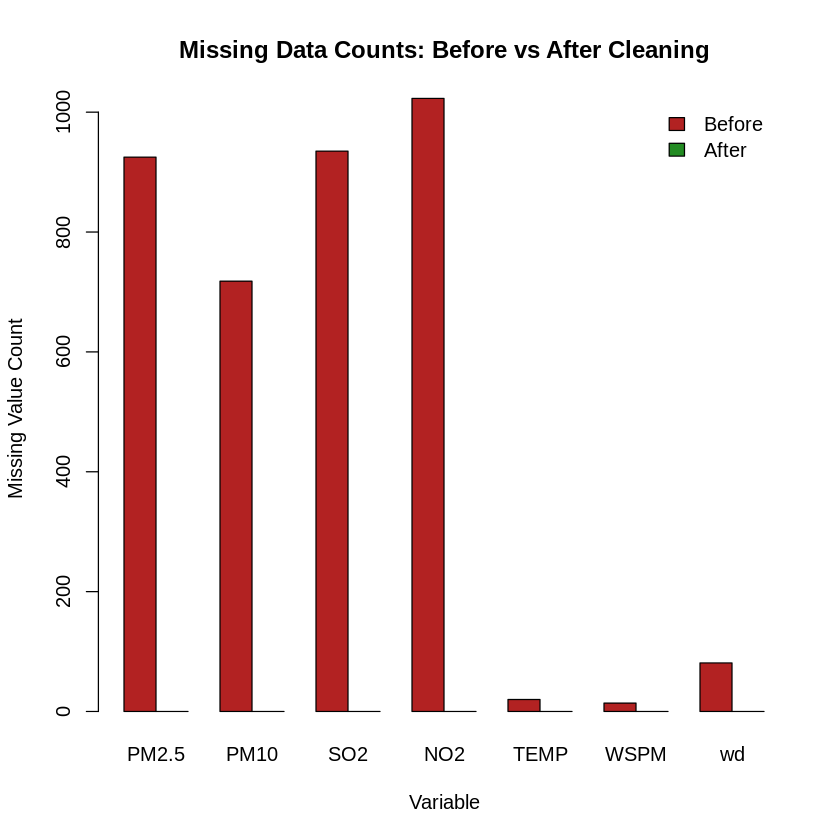

In [12]:
chart_matrix <- rbind(result_table$Missing_Before, result_table$Missing_After)
colnames(chart_matrix) <- result_table$Variable
rownames(chart_matrix) <- c("Before", "After")

barplot(chart_matrix,
        beside = TRUE,
        col = c("firebrick", "forestgreen"),
        main = "Missing Data Counts: Before vs After Cleaning",
        xlab = "Variable",
        ylab = "Missing Value Count",
        legend.text = TRUE,
        args.legend = list(x = "topright", bty = "n"))


# Task 10: Export the Cleaned Dataset

In [13]:
write.csv(beijing_df, "cleaned_beijing_air_quality.csv", row.names = FALSE)
cat("Export complete -> cleaned_beijing_air_quality.csv\n")


Export complete -> cleaned_beijing_air_quality.csv


### Interpretation

This experiment walked through a complete missing-data workflow on the Beijing air-quality station file. After loading the data safely with `tryCatch`, the three special values NA, NULL, and NaN were demonstrated separately to show how R distinguishes an absent observation from an empty object and from an undefined arithmetic result. A reusable `summarize_missing()` function reported that the selected pollutant and weather columns each carried only a small fraction of missing entries, well under the 20% warning threshold. Numeric gaps were filled using a loop-driven median imputation, while the categorical wind-direction column was filled using its most frequent value. A dedicated error-handling function guarded against non-numeric columns, missing columns, and all-NA columns without crashing the script. The before/after comparison table and bar chart confirm every tracked variable reached zero missing values, and the cleaned dataset was exported for downstream analysis.
